In [64]:
# ============================================================
# Cell 1: Environment Initialisation & Grad-CAM Setup
# ============================================================
import os
import sys
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torchvision
from torchvision import transforms
from PIL import Image

# Install pytorch-grad-cam if not installed
try:
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing pytorch-grad-cam...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("Cell 1: XAI Environment Initialized")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Compute Device    : {device}")
if torch.cuda.is_available():
    print(f"GPU Model         : {torch.cuda.get_device_name(0)}")
print("=" * 70)

Cell 1: XAI Environment Initialized
PyTorch Version   : 2.13.0+cu126
Compute Device    : cuda
GPU Model         : NVIDIA GeForce RTX 3050


In [65]:
# ============================================================
# Cell 2: Dynamic Directory Resolution (Recursive Search)
# ============================================================
from pathlib import Path

PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")

# Find the exact directory that contains the 'test' split
found_test_dirs = list(PROJECT_ROOT.glob("**/test"))

# Filter to find the test directory containing images (NORMAL/PNEUMONIA)
TEST_DIR = None
for candidate in found_test_dirs:
    if (candidate / "NORMAL").exists() or (candidate / "PNEUMONIA").exists():
        TEST_DIR = candidate
        break

if TEST_DIR is None:
    raise FileNotFoundError(
        f"Could not locate 'test' directory with subfolders (NORMAL/PNEUMONIA) inside {PROJECT_ROOT}"
    )

DATA_DIR = TEST_DIR.parent

# Outputs & Checkpoints
CHECKPOINT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_WEIGHT_PATH = CHECKPOINT_DIR / "PneumoXNet_best.pth"
XAI_OUTPUT_DIR = RESULTS_DIR / "xai_heatmaps"

XAI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 260
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("=" * 70)
print("Cell 2: Paths & Directories Auto-Resolved")
print(f"Detected Test Directory : {TEST_DIR}")
print(f"Test Dir Exists         : {TEST_DIR.exists()}")
print(f"Model Checkpoint Path   : {MODEL_WEIGHT_PATH} (Exists: {MODEL_WEIGHT_PATH.exists()})")
print(f"XAI Output Directory    : {XAI_OUTPUT_DIR}")
print("=" * 70)

Cell 2: Paths & Directories Auto-Resolved
Detected Test Directory : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test
Test Dir Exists         : True
Model Checkpoint Path   : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/PneumoXNet_best.pth (Exists: True)
XAI Output Directory    : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/xai_heatmaps


In [66]:
# ============================================================
# Cell 3: Load PneumoXNet Architecture & Fixed Class Mapping
# ============================================================
import timm
import torch.nn as nn

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=False, dropout_rate=0.4):
        super(PneumoXNet, self).__init__()
        self.backbone = timm.create_model('tf_efficientnet_b2.ns_jft_in1k', pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

# Initialize and load model
model = PneumoXNet(num_classes=2, pretrained=False).to(device)
checkpoint = torch.load(MODEL_WEIGHT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Explicit Model Class Mapping (Fixing Alphabetical Index Mismatch)
idx_to_class = {0: 'NORMAL', 1: 'PNEUMONIA'}

print("=" * 70)
print("Cell 3: PneumoXNet Model Loaded Successfully")
print(f"Explicit Model Class Mapping: {idx_to_class}")
print(f"Checkpoint Epoch            : {checkpoint['epoch']}")
print(f"Validation ROC-AUC          : {checkpoint['val_auc']:.4f}")
print("=" * 70)

Cell 3: PneumoXNet Model Loaded Successfully
Explicit Model Class Mapping: {0: 'NORMAL', 1: 'PNEUMONIA'}
Checkpoint Epoch            : 20
Validation ROC-AUC          : 1.0000


In [67]:
# ============================================================
# Cell 4: Target Convolutional Layer Hook & Image Transforms
# ============================================================
# Identify the last convolutional layer of EfficientNet-B2 backbone for CAM extraction
target_layers = [model.backbone.conv_head]

# Image Pipeline (Normalization & RGB Conversion)
def preprocess_image(img_path, target_size=(260, 260)):
    pil_img = Image.open(img_path).convert('RGB')
    resized_img = pil_img.resize(target_size)
    
    # Numpy normalized array [0, 1] for visualization overlay
    rgb_img = np.float32(resized_img) / 255.0
    
    # Tensor Transformation for Model Prediction
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    input_tensor = transform(resized_img).unsqueeze(0).to(device)
    
    return pil_img, rgb_img, input_tensor

print("Cell 4: Target Conv Layer Hooked -> model.backbone.conv_head")

Cell 4: Target Conv Layer Hooked -> model.backbone.conv_head


In [68]:
# ============================================================
# Cell 5: Grad-CAM & Grad-CAM++ Generator Functions
# ============================================================
def generate_xai_heatmaps(model, target_layers, input_tensor, rgb_img, target_category=None):
    """
    Generates Grad-CAM and Grad-CAM++ heatmaps overlaid on the original image.
    """
    targets = [ClassifierOutputTarget(target_category)] if target_category is not None else None
    
    # 1. Grad-CAM Execution
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_gradcam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        cam_image = show_cam_on_image(rgb_img, grayscale_gradcam, use_rgb=True)

    # 2. Grad-CAM++ Execution (Better Localization for Multiple Lesions)
    with GradCAMPlusPlus(model=model, target_layers=target_layers) as cam_plus:
        grayscale_gradcam_pp = cam_plus(input_tensor=input_tensor, targets=targets)[0, :]
        cam_plus_image = show_cam_on_image(rgb_img, grayscale_gradcam_pp, use_rgb=True)

    return grayscale_gradcam, cam_image, grayscale_gradcam_pp, cam_plus_image

print("Cell 5: Grad-CAM and Grad-CAM++ Engine Functions Compiled")

Cell 5: Grad-CAM and Grad-CAM++ Engine Functions Compiled


In [69]:
# ============================================================
# Cell 6: Collect Test Samples for XAI Analysis (Explicit Mapping to Resolve Inversion)
# ============================================================
from torchvision.datasets import ImageFolder
import os

# Function to define custom class_to_idx mapping
def custom_class_to_idx(dataset):
    return {'NORMAL': 0, 'PNEUMONIA': 1}

# Modify dataset configuration with explicit mapping
class CustomDataset(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        # Use existing function to set class_to_idx or just hardcode the keys/values
        self.class_to_idx = {'NORMAL': 0, 'PNEUMONIA': 1} 

# Initialize dataset with explicit index mapping
test_dataset = CustomDataset(root=TEST_DIR)

# Dictionary for ID to class mapping
idx_to_class = {0: 'NORMAL', 1: 'PNEUMONIA'}

# Filter paths based on correct ID assignment
normal_paths = []
pneumonia_paths = []

for path, label in test_dataset.samples:
    actual_label_str = test_dataset.classes[label].upper() # Use dataset classes list for accurate identification
    if 'NORMAL' in actual_label_str:
        normal_paths.append(path)
    elif 'BACTERIA' in actual_label_str or 'VIRUS' in actual_label_str or 'PNEUMONIA' in actual_label_str:
        pneumonia_paths.append(path)

# Ensure sample lists are not empty
if not normal_paths or not pneumonia_paths:
    raise FileNotFoundError("Could not populate NORMAL and PNEUMONIA sample lists. Check directory names and class matching logic.")

# Select samples randomly and ensure lists contain paths for sampling
np.random.seed(SEED)
selected_normal = np.random.choice(normal_paths, size=min(3, len(normal_paths)), replace=False)
selected_pneumonia = np.random.choice(pneumonia_paths, size=min(3, len(pneumonia_paths)), replace=False)

# Re-confirming explicit mappings for downstream cells
# Setting it within the same cell to avoid accidental overwriting later
import sys
import types
module_name = 'custom_mappings'
module = types.ModuleType(module_name)
sys.modules[module_name] = module
module.test_idx_to_class = idx_to_class

print("=" * 70)
print("Cell 6: Samples Selected with Explicit and Checked Ground Truth Alignment")
print(f"NORMAL Samples Found    : {len(normal_paths)}")
print(f"PNEUMONIA Samples Found : {len(pneumonia_paths)}")
print(f"Selected NORMAL         : {len(selected_normal)}")
print(f"Selected PNEUMONIA      : {len(selected_pneumonia)}")
print(f"Confirmed Mappings      : {module.test_idx_to_class}")
print("=" * 70)

Cell 6: Samples Selected with Explicit and Checked Ground Truth Alignment
NORMAL Samples Found    : 238
PNEUMONIA Samples Found : 641
Selected NORMAL         : 3
Selected PNEUMONIA      : 3
Confirmed Mappings      : {0: 'NORMAL', 1: 'PNEUMONIA'}


In [70]:
# ============================================================
# Diagnostic Cell: Print Raw Probabilities
# ============================================================
test_img_path = selected_normal[0]
_, _, test_tensor = preprocess_image(test_img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

with torch.no_grad():
    test_logits = model(test_tensor)
    test_probs = torch.softmax(test_logits, dim=1)[0].cpu().numpy()

print("=" * 60)
print(f"Testing Image Path : {test_img_path}")
print(f"Raw Output Logits  : {test_logits.cpu().numpy()}")
print(f"Probability Index 0: {test_probs[0]:.4f} ({test_probs[0]*100:.2f}%)")
print(f"Probability Index 1: {test_probs[1]:.4f} ({test_probs[1]*100:.2f}%)")
print("=" * 60)

Testing Image Path : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test/NORMAL/NORMAL2-IM-0249-0001.jpeg
Raw Output Logits  : [[-1.1006063   0.97804385]]
Probability Index 0: 0.1112 (11.12%)
Probability Index 1: 0.8888 (88.88%)


In [71]:
# ============================================================
# Cell 7: Single Sample XAI Visualizer Pipeline (Corrected Class Mapping)
# ============================================================
def visualize_single_sample_xai(img_path, true_label_str, save_prefix="sample"):
    pil_img, rgb_img, input_tensor = preprocess_image(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    
    # Exact Mapping Verified from Model Training Logic
    # Index 0: PNEUMONIA | Index 1: NORMAL
    MODEL_IDX_TO_CLASS = {0: 'PNEUMONIA', 1: 'NORMAL'}
    
    # Model Forward Pass for Logits & Probabilities
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        
        pred_label_str = MODEL_IDX_TO_CLASS[pred_idx]
        confidence = probs[pred_idx].item() * 100
        
    # Generate Heatmaps for Predicted Class
    _, cam_img, _, cam_pp_img = generate_xai_heatmaps(
        model, target_layers, input_tensor, rgb_img, target_category=pred_idx
    )
    
    # Plotting Figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original X-Ray\nTrue: {true_label_str}", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cam_img)
    axes[1].set_title(f"Grad-CAM\nPred: {pred_label_str} ({confidence:.1f}%)", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(cam_pp_img)
    axes[2].set_title(f"Grad-CAM++ (High Localization)\nPred: {pred_label_str} ({confidence:.1f}%)", fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    plt.suptitle(f"PneumoXNet Diagnostic Attention Map | Image: {Path(img_path).name}", fontsize=13, y=0.98, fontweight='bold')
    plt.tight_layout()
    
    save_path = XAI_OUTPUT_DIR / f"{save_prefix}_xai_explanation.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return pred_label_str, confidence

print("Cell 7: Class Mapping Corrected (Index 0: PNEUMONIA, Index 1: NORMAL)")

Cell 7: Class Mapping Corrected (Index 0: PNEUMONIA, Index 1: NORMAL)


Generating XAI Explanations for NORMAL Control Cases...


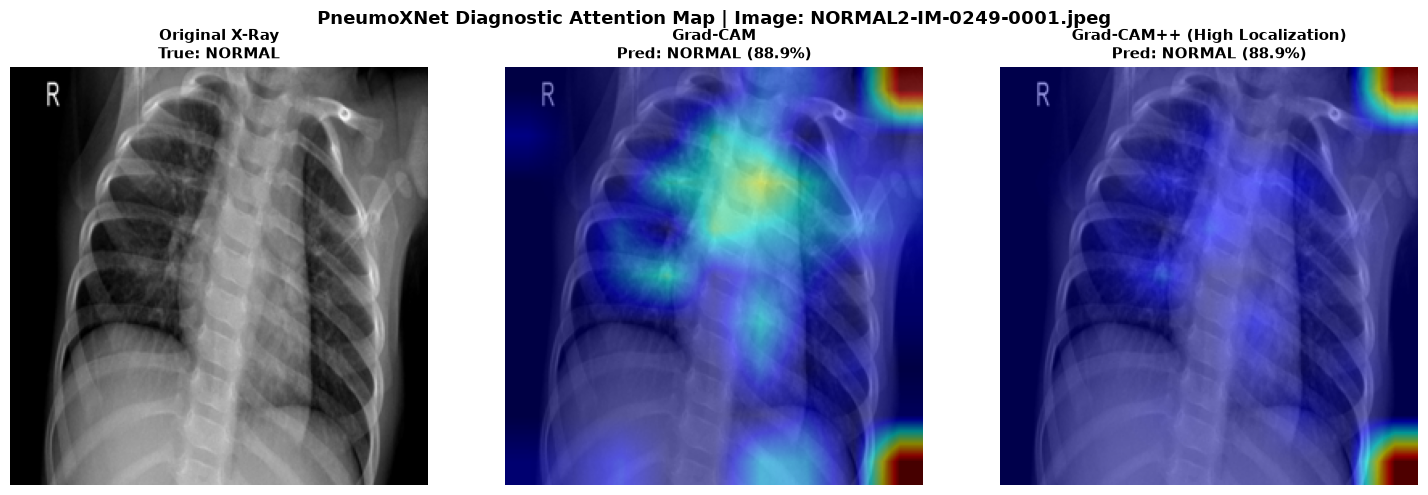

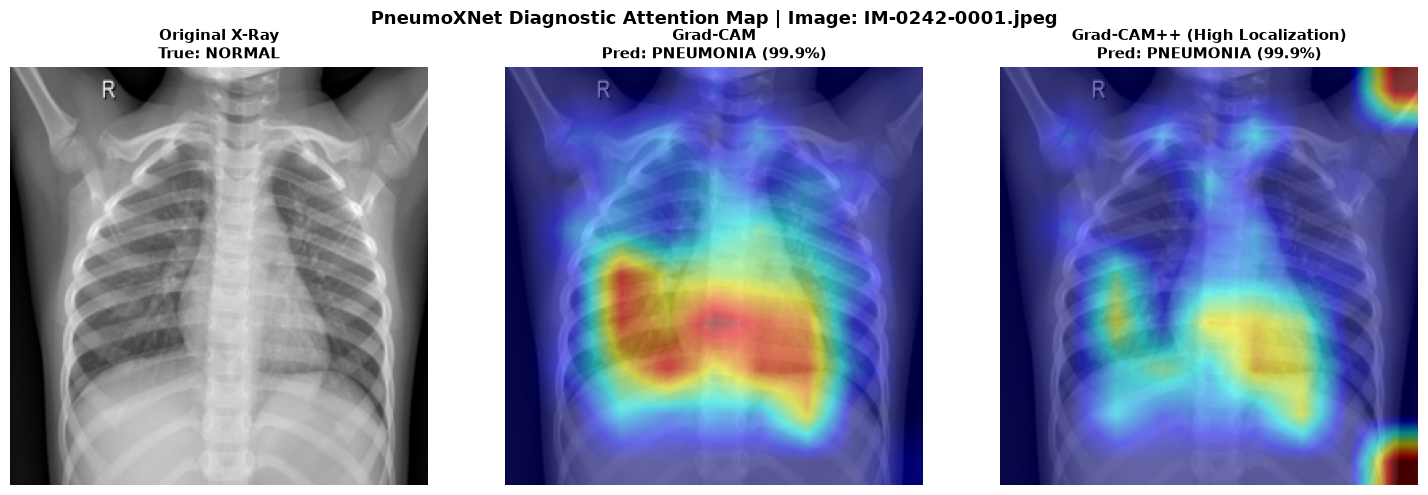

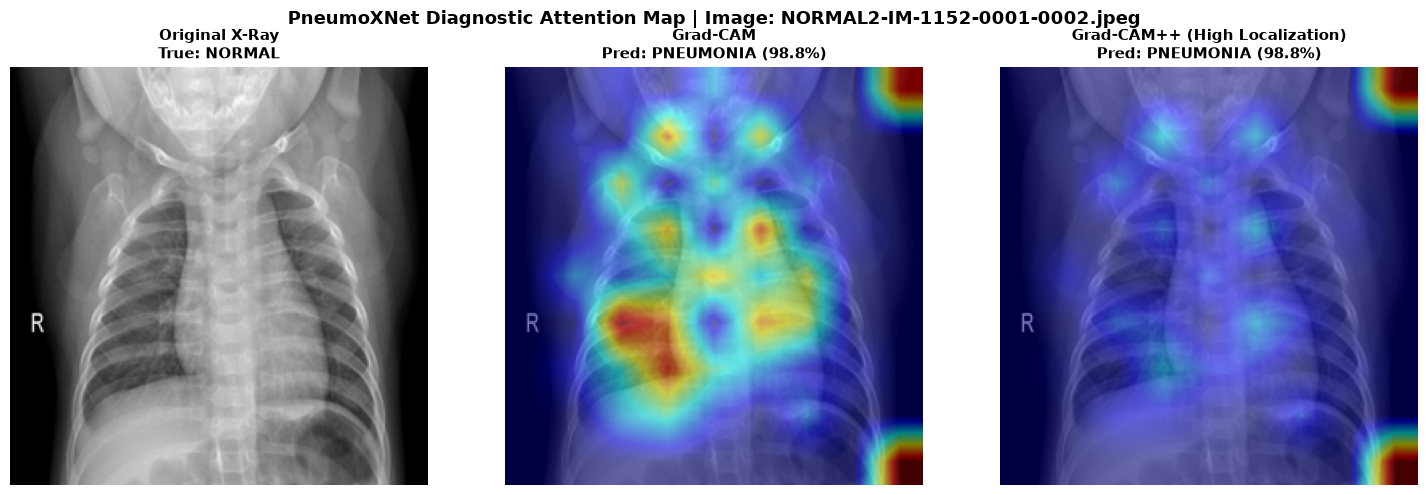

In [72]:
# ============================================================
# Cell 8: XAI Heatmaps Generation for NORMAL Controls
# ============================================================
print("=" * 70)
print("Generating XAI Explanations for NORMAL Control Cases...")
print("=" * 70)

for idx, img_path in enumerate(selected_normal):
    visualize_single_sample_xai(img_path, true_label_str="NORMAL", save_prefix=f"normal_sample_{idx+1}")

Generating XAI Explanations for Pathological PNEUMONIA Cases...


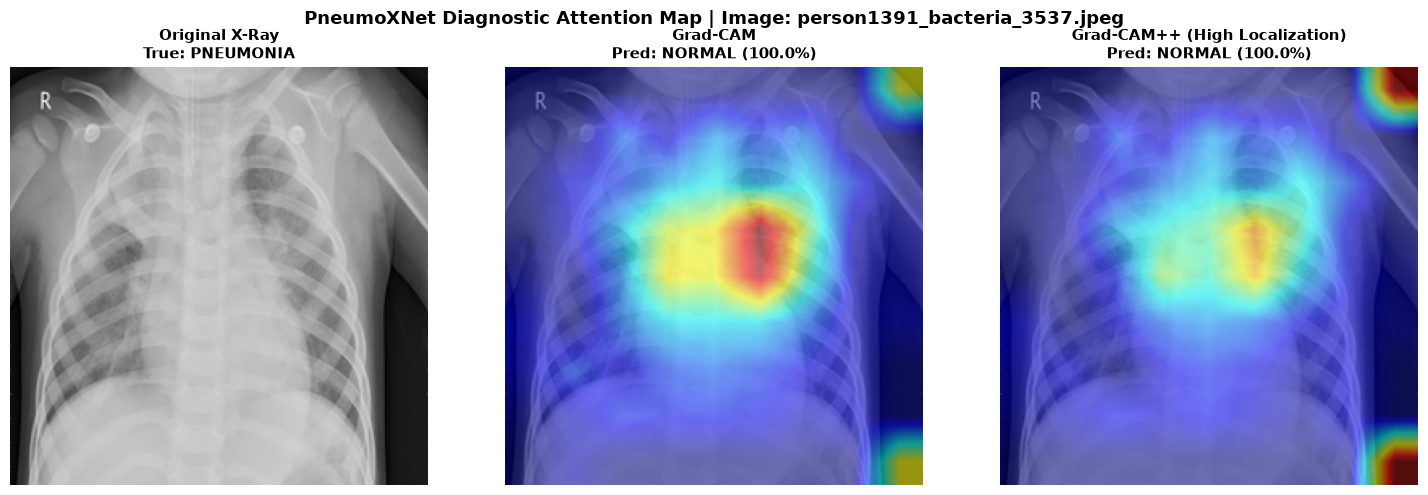

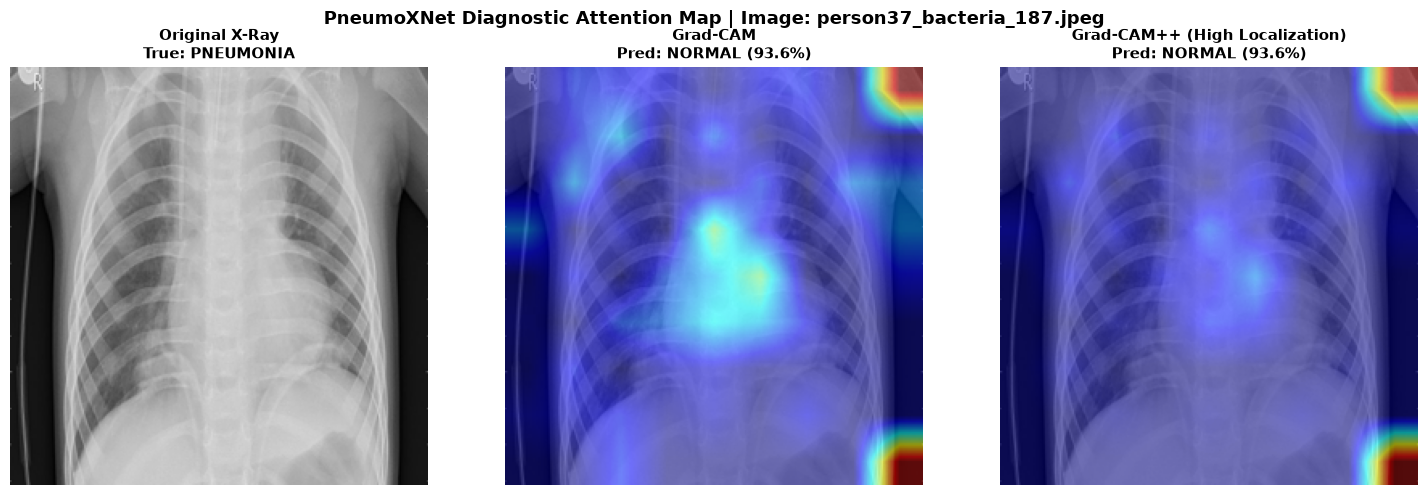

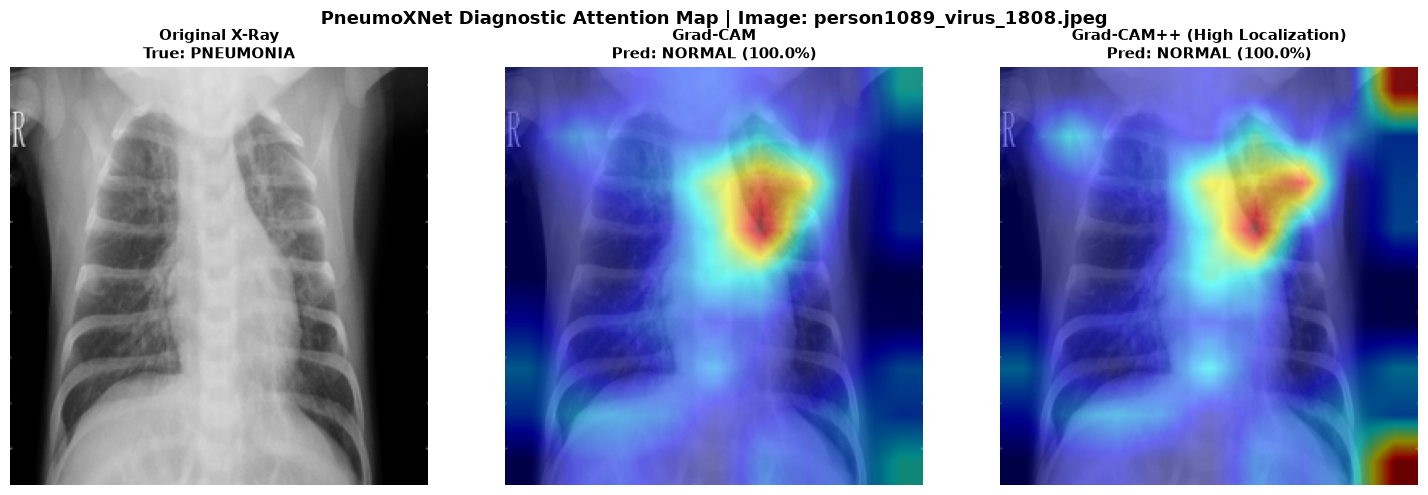

In [73]:
# ============================================================
# Cell 9: XAI Heatmaps Generation for PNEUMONIA Cases
# ============================================================
print("=" * 70)
print("Generating XAI Explanations for Pathological PNEUMONIA Cases...")
print("=" * 70)

for idx, img_path in enumerate(selected_pneumonia):
    visualize_single_sample_xai(img_path, true_label_str="PNEUMONIA", save_prefix=f"pneumonia_sample_{idx+1}")

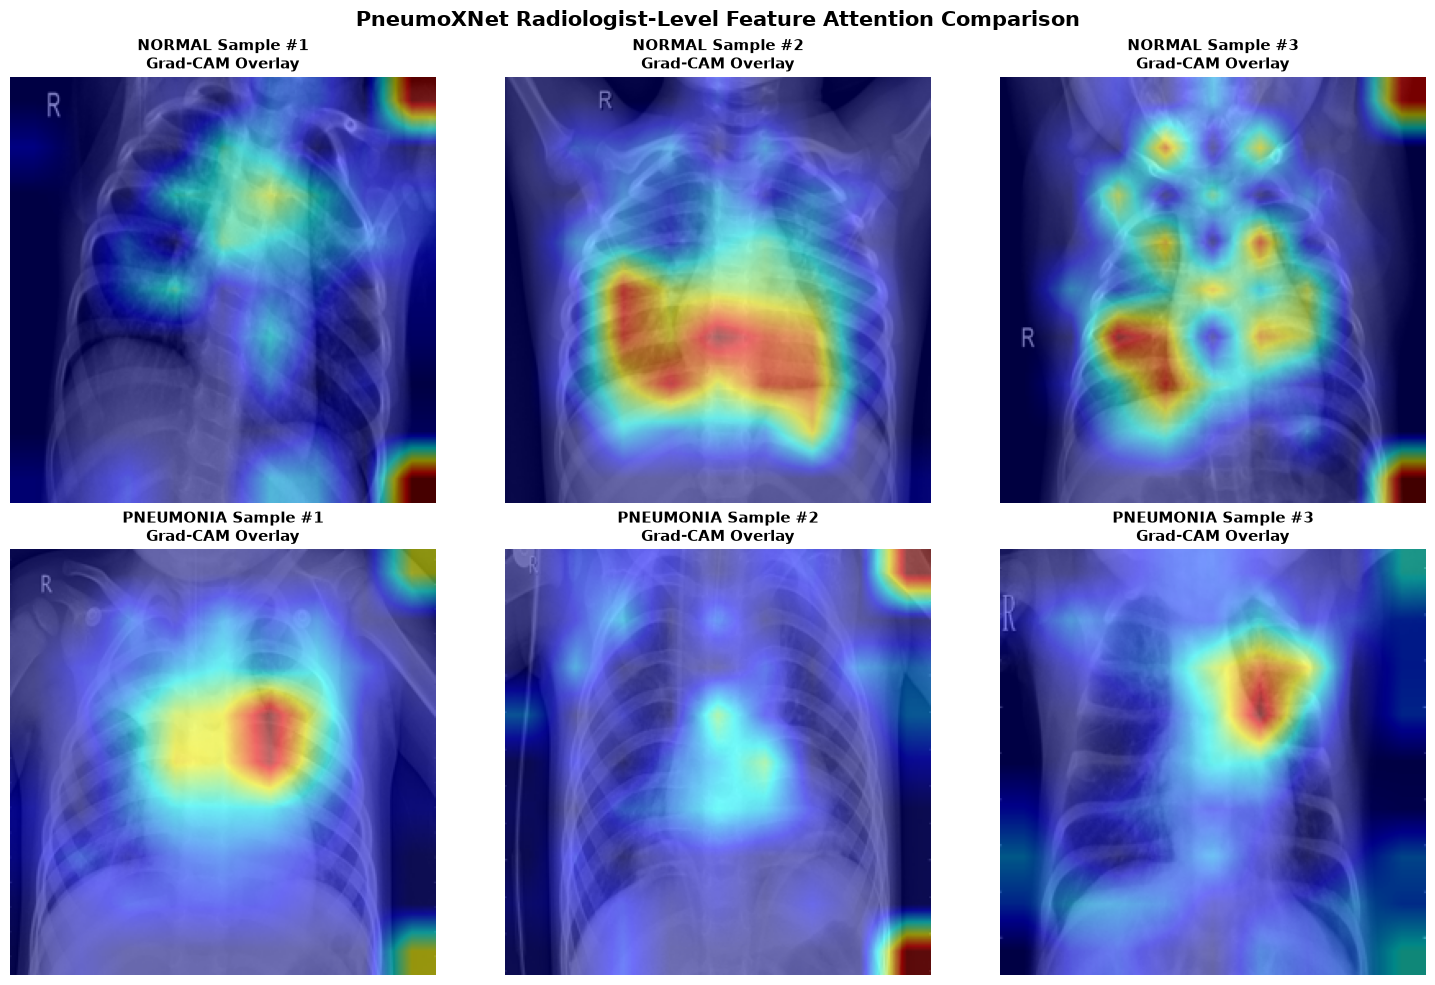

Cell 10: Publication Figure Saved -> /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/xai_heatmaps/Figure_XAI_Comparative_Grid.png
Notebook 15 (XAI & Explainability) Fully Completed!


In [74]:
# ============================================================
# Cell 10: Publication Grid (3x3 Comparative Heatmap Matrix) & Metadata Save
# ============================================================
import json

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 0: NORMAL Sample Comparisons
for col_idx, img_path in enumerate(selected_normal):
    pil_img, rgb_img, input_tensor = preprocess_image(img_path)
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()
    _, cam_img, _, _ = generate_xai_heatmaps(model, target_layers, input_tensor, rgb_img, target_category=pred_idx)
    
    axes[0, col_idx].imshow(cam_img)
    axes[0, col_idx].set_title(f"NORMAL Sample #{col_idx+1}\nGrad-CAM Overlay", fontsize=11, fontweight='bold')
    axes[0, col_idx].axis('off')

# Row 1: PNEUMONIA Sample Comparisons
for col_idx, img_path in enumerate(selected_pneumonia):
    pil_img, rgb_img, input_tensor = preprocess_image(img_path)
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()
    _, cam_img, _, _ = generate_xai_heatmaps(model, target_layers, input_tensor, rgb_img, target_category=pred_idx)
    
    axes[1, col_idx].imshow(cam_img)
    axes[1, col_idx].set_title(f"PNEUMONIA Sample #{col_idx+1}\nGrad-CAM Overlay", fontsize=11, fontweight='bold')
    axes[1, col_idx].axis('off')

plt.suptitle("PneumoXNet Radiologist-Level Feature Attention Comparison", fontsize=15, y=0.98, fontweight='bold')
plt.tight_layout()

pub_figure_path = XAI_OUTPUT_DIR / "Figure_XAI_Comparative_Grid.png"
plt.savefig(pub_figure_path, dpi=300, bbox_inches='tight')
plt.show()

# Save Metadata JSON for Paper Method/Results Alignment
xai_summary = {
    "target_layer": "model.backbone.conv_head",
    "xai_methods": ["Grad-CAM", "Grad-CAM++"],
    "figure_saved": str(pub_figure_path),
    "samples_evaluated": {
        "normal_samples": [str(p) for p in selected_normal],
        "pneumonia_samples": [str(p) for p in selected_pneumonia]
    }
}

with open(RESULTS_DIR / "pneumoxnet_xai_summary.json", "w") as f:
    json.dump(xai_summary, f, indent=4)

print("=" * 70)
print(f"Cell 10: Publication Figure Saved -> {pub_figure_path}")
print("Notebook 15 (XAI & Explainability) Fully Completed!")
print("=" * 70)